# 02 Model development
Time-ordered splits only. Models: WoE scorecard (benchmark), multi-state hazard model (production), GBM challenger, LGD (cure x loss-given-no-cure).

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, json
from IPython.display import Image, display
pd.set_option('display.width', 200)
O = '../outputs/'
show = lambda f: display(pd.read_csv(O + f).round(4))
print(open('../config.yaml').read().split('splits:')[1].split('staging:')[0])

                      # by observation month
  pd12_train_end: "2021-12"  # 12m labels known by end-2022 (12m embargo)
  pd12_valid: ["2022-01", "2022-12"]
  pd12_test: ["2023-01", "2024-12"]
  hazard_train_end: "2022-12"
  hazard_valid: ["2023-01", "2023-12"]
  hazard_test: ["2024-01", "2025-12"]
  lgd_train_end: "2022-12"   # by default month / resolution month




## Scorecard information values

In [2]:
show('scorecard_iv.csv')

,variable,information_value
0,st,1.3518
1,score_z,0.4927
2,dti,0.0726
3,emp,0.0473
4,age,0.0124
5,cltv,0.0078
6,ltv0,0.0051


## Scenario paths

In [3]:
show('scenario_paths.csv')

,scenario,year,prime_end,unemp_end,hpi_yoy_end,cpi_end
0,base,2026,10.50,31.6,3.00,4.00
1,base,2027,10.50,31.3,3.25,4.25
2,base,2028,10.50,31.0,3.50,4.50
3,upside,2026,9.25,31.1,6.00,3.50
4,upside,2027,9.25,30.3,6.50,3.50
5,upside,2028,9.25,29.5,7.00,3.50
6,downside,2026,12.75,34.0,-4.00,6.50
7,downside,2027,12.75,35.5,-4.00,5.75
8,downside,2028,11.75,34.5,1.00,5.00


## ECL by stage and scenario

,stage,loans,ead,ecl_base,ecl_upside,ecl_downside,ecl_weighted,overlay,ecl_final,coverage_pct
0,1,18057.0,2.016867e+10,5.014382e+07,4.441865e+07,6.243322e+07,5.268560e+07,61078.7856,5.274668e+07,0.2615
1,2,1967.0,2.921496e+09,5.181875e+07,4.503431e+07,6.965145e+07,5.581167e+07,238688.5931,5.605036e+07,1.9185
2,3,915.0,1.252712e+09,1.790924e+08,1.755753e+08,1.876250e+08,1.809488e+08,0.0000,1.809488e+08,14.4446
3,Total,20939.0,2.434288e+10,2.810550e+08,2.650283e+08,3.197097e+08,2.894461e+08,299767.3787,2.897458e+08,1.1903


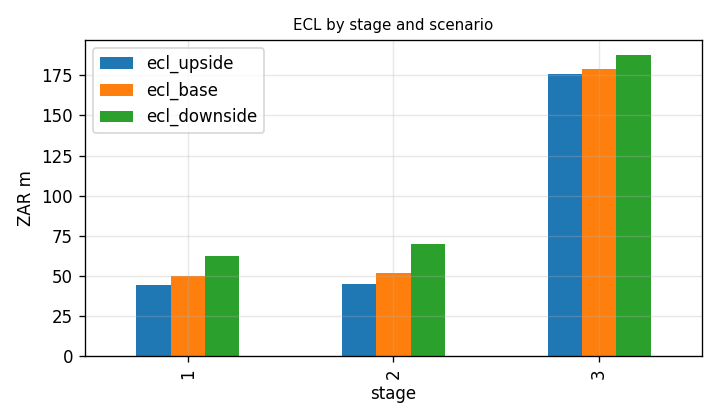

,ltv_band,loans,ead,ecl_final,coverage_pct
0,70-80%,4723,5.388178e+09,5.620666e+07,1.0431
1,80-90%,6599,7.741539e+09,9.372921e+07,1.2107
2,90-100%,7642,8.891794e+09,1.167138e+08,1.3126
3,<=70%,1975,2.321368e+09,2.309613e+07,0.9949


,bureau_band,loans,ead,ecl_final,coverage_pct
0,A,2714,3.297631e+09,8.912229e+06,0.2703
1,B,4923,5.908070e+09,3.382150e+07,0.5725
2,C,6478,7.517107e+09,7.999142e+07,1.0641
3,D,4663,5.236910e+09,9.201499e+07,1.7570
4,E,2161,2.383161e+09,7.500570e+07,3.1473


In [4]:
show('ecl_by_stage.csv'); display(Image('../docs/figures/ecl_by_stage_scenario.png')); show('ecl_by_ltv_band.csv'); show('ecl_by_score_band.csv')

## Stage migration

,from,Exited,Stage 1,Stage 2,Stage 3
0,Stage 1,0.0455,0.9347,0.0085,0.0113
1,Stage 2,0.0432,0.1542,0.7348,0.0679
2,Stage 3,0.3976,0.0886,0.0473,0.4664


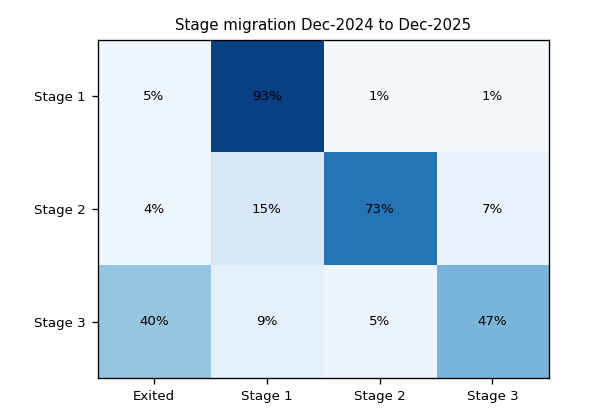

In [5]:
show('stage_migration_pct.csv'); display(Image('../docs/figures/stage_migration.png'))

## Sensitivities

In [6]:
show('sensitivity_staging.csv'); show('sensitivity_scenario_weights.csv')

,test,multiple,absolute_pp,stage2_share_pct,stage2_ead_pct,total_ecl
0,SICR thresholds,1.5,0.25,34.8775,40.1545,3.503795e+08
1,SICR thresholds,1.5,0.50,27.6995,32.9581,3.449323e+08
2,SICR thresholds,1.5,1.00,16.6722,20.6814,3.284560e+08
3,SICR thresholds,2.0,0.25,20.9513,25.3921,3.181493e+08
4,SICR thresholds,2.0,0.50,18.2673,22.5577,3.166910e+08
5,SICR thresholds,2.0,1.00,12.2403,15.6324,3.093563e+08
6,SICR thresholds,2.5,0.25,10.5688,13.3891,2.901051e+08
7,SICR thresholds,2.5,0.50,9.3940,12.0014,2.894461e+08
8,SICR thresholds,2.5,1.00,6.6097,8.6312,2.862270e+08
9,SICR thresholds,3.0,0.25,4.6182,6.0033,2.764034e+08


,weights,base,upside,downside,ecl,coverage_pct
0,Illustrative 50/20/30,0.5000,0.2000,0.3000,2.894461e+08,1.1890
1,Base-heavy 70/10/20,0.7000,0.1000,0.2000,2.871833e+08,1.1797
2,Equal 33/33/33,0.3333,0.3333,0.3333,2.885977e+08,1.1856
3,Downside-heavy 40/10/50,0.4000,0.1000,0.5000,2.987797e+08,1.2274
4,Optimistic 40/40/20,0.4000,0.4000,0.2000,2.823753e+08,1.1600
5,100% base,1.0000,0.0000,0.0000,2.810550e+08,1.1546
6,100% downside,0.0000,0.0000,1.0000,3.197097e+08,1.3134
